# MODEL SELECTION IN CONTEXT AND USE

First of all, in the context of Oftacmology, the IA models can help a lot in the context of diagnosis, this statement think of the use of SR images more for complement for MEDIC INSTRUMENTATION, we cannot tell if the SR Images help better for IA models for they automaticly give diagnosos, following this idea, we will center on give the SR Image justifying this helps the subjetive doctor analysis, that COULD BE useful for later IA AUTOMATIC DIAGNOSIS, but this study is focus on SR Images and criteria above this concept. This doesnt mean we will not reach this topic, we can get to DL model for automatic diagnosisi complementing this devepment in SR. But that can be keep for later.Since now, we center on SR.

The criteria that we will be using will be based on another studies so we can build our own devepment with the best characteristics possible.
Once this noticed, we will determine the context and the needs of the MODEL ARCHITECTURE listed below:

## 1. **Input Resolution-Output Resolution:** 
Based on the dataset images, we can determinate the SR resolution just as and standart that works with the data flow proposed.

In [3]:
import cv2
img_r = r"E:\Proyects Python based\ProyectoAvanzado2\data\raw\M1\Aptos_messidor_dataset\Aptos_messidor_dataset\class_0\0a4e1a29ffff_aug_0.png"
img = cv2.imread(img_r)
print("The image resolution is: ",img.shape)

The image resolution is:  (512, 512, 3)


We can see that the example image have RGB channels and a squared shape of 512*512, who gives us the spected output

$$
\text{Input LR Image}
\;\rightarrow\;
\boxed{\text{Model}}
\;\rightarrow\;
\boxed{\text{OUTPUT}\;|\;512 \times 512}
$$

For the Input in LR, we can adjust at medical standars usually used that are *(2,4,8) so we will adjust this standar at our work.
To sumarize the information we will show  it below:

| Scale Factor | LR Resolution | Degradation Severity | Clinical / Industrial Interpretation |
|---|---|---|---|
| ×2 | 256×256 | Mild | Simulates hardware with a slight reduction in resolution. Minimal loss of microstructure. |
| ×4 | 128×128 | Moderate (Standard) | Realistic scenario in the SR literature. Significant loss of fine details (small vessels). |
| ×8 | 64×64 | Severe (Limit) | Extreme scenario to analyze hardware limits. High loss of spatial information. |

## 2. **Dedradation methods - selection and purpose:**

In order to keep building the model, we have to reach to degradation types and our selection, but this section is focused on explanation and understaning of those degradation models, also the explanation for what what models shoud be better for this project.

The ecuation based for generating  LR images form SR images is the following one:

$$ LR = D(HR) $$

Where D is the degradation procces, who re-defining we get a more universal form in the form shown above:

$$
\text{LR} = (\text{HR} \otimes k) \downarrow_s + n
$$

where:

- **HR**: original high-resolution image  
- **k**: blur kernel  
- **↓\_s**: downsampling operator with scale factor \(s\)  
- **n**: additive noise

To aboard this degradation we go back to our problem in context, since the retinal images  are obtained from cameras, we have to simulate  our procces of degradation thinking primarly in that. That already clarified, we can go back and check in the STATE-OF-ART review to check how is the dregradation selecion in cameras from medical usage. 

### **1. Downsampling methods:**
Downsampling means sub-register information of a certain nature, in this case, will be passing from 512*512 to lower resolutions.

#### 1.1 Nearest Neighbord:

For educational pursposes we will be making a simple example of every downsamping method.
In this case, we start with a simple 4*4
 image as we see:




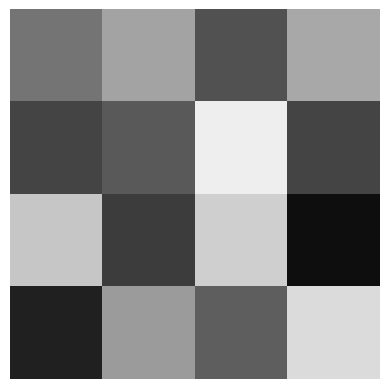

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 2x2 single-channel (grayscale) image with random values in [0, 255]
img = np.random.randint(0, 256, (4, 4, 1), dtype=np.uint8)

plt.imshow(img[:, :, 0], cmap='grey', vmin=0, vmax=255)
plt.axis('off')
plt.show()